## Random Forest on Glass Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [2]:
excel_file = pd.ExcelFile("glass.xlsx")
print(excel_file.sheet_names)

['Description', 'glass']


In [3]:
#Loading dataset
df = pd.read_excel("glass.xlsx",sheet_name=1)
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


### Exploratory Data Analysis

In [4]:
df.shape

(214, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [6]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [7]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

### Visualizations

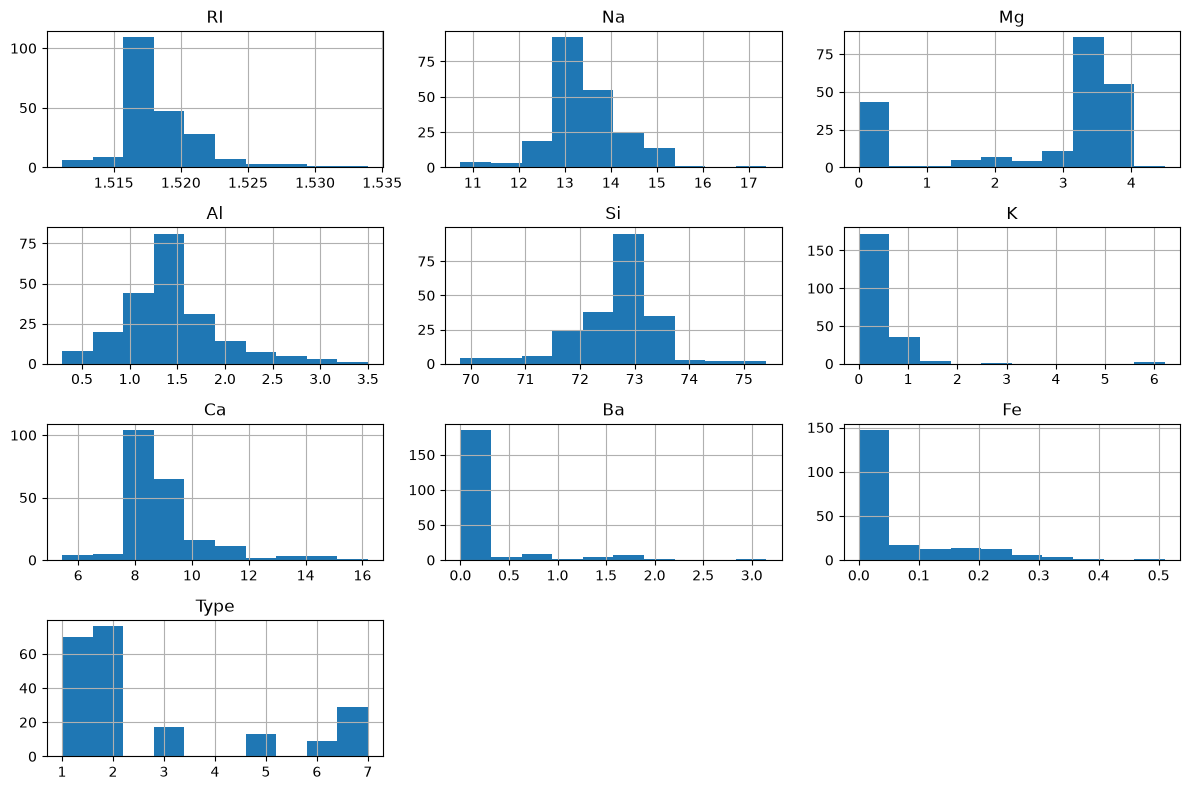

In [9]:
#Histogram
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

* RI values are mostly concentrated between 1.515 and 1.520, with a few higher values.
* Na values are mainly distributed between 12.5 and 14, showing a slight right skew.
* Mg values are mostly between 3 and 4, while a few samples have very low values.
* Al values are concentrated around 1 to 1.5, with a few higher observations.
* Si values are closely clustered around 72 to 73, indicating low variation.
* K values are mostly close to zero, with only a few high-value outliers.
* Ca values are mainly distributed between 8 and 10, with a few higher values.
* Ba values are zero or very low for most samples, while only a few have higher concentrations.
* Fe values are very low in most samples, with a small number of higher observations.
* The target variable is imbalanced, as Types 1 and 2 have more samples than the other glass types.


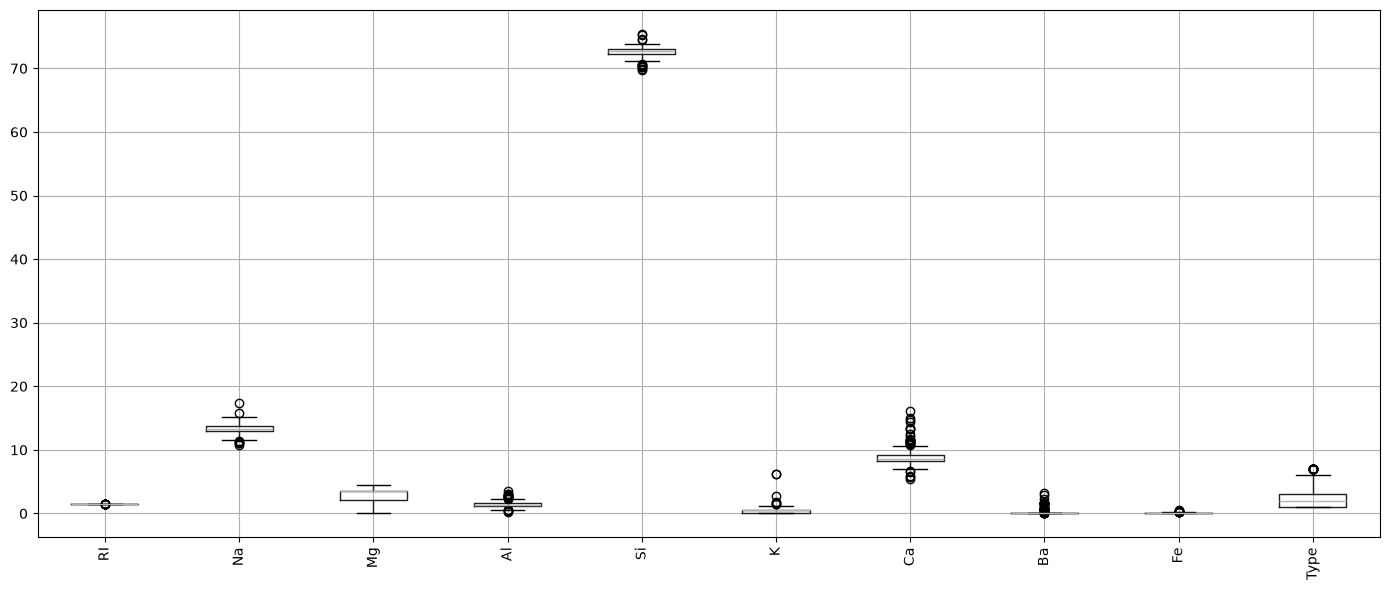

In [10]:
#Boxplots
df.boxplot(figsize=(14,6), rot=90)
plt.tight_layout()
plt.show()

* RI shows a small spread with only a few outliers.
* Na contains a few outliers on both the lower and higher sides.
* Mg has a moderate spread with only a few outlier values.
* Al shows several outliers, indicating some unusually high values.
* Si has a narrow spread with a few outliers at both ends.
* K is highly right-skewed, with several high-value outliers.
* Ca contains many outliers, especially on the higher side.
* Ba has most values near zero, with a few noticeable high-value outliers.
* Fe values are mostly close to zero, with only a few outliers.
* The target variable shows a wide spread because it consists of multiple glass classes.


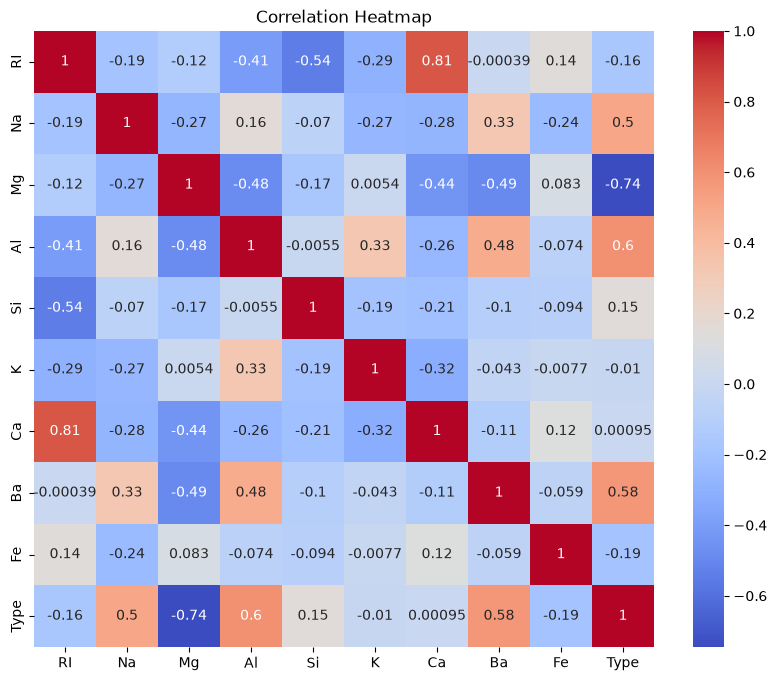

In [ ]:
#Corelation
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

* RI and Ca have a strong positive correlation, indicating they increase together.
* Mg has a strong negative correlation with the target variable (Type).
* Al and Type show a moderate positive correlation.
* Ba also has a moderate positive correlation with the target variable.
* Na has a moderate positive correlation with the target variable.
* Mg is negatively correlated with Al, Ca, and Ba.
* Most other feature pairs have weak or very low correlations.


### Data Preprocessing

In [ ]:
X = df.iloc[:,:-1] #Except the last column
y = df.iloc[:,-1]  #Only last column

In [13]:
#Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42,stratify=y)

In [14]:
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (171, 9)
Test Shape: (43, 9)


### Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100,random_state=42) #100 Decision Trees

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [16]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average="weighted"))
print("Recall   :", recall_score(y_test, rf_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, rf_pred, average="weighted"))

Accuracy : 0.813953488372093
Precision: 0.8261776982707214
Recall   : 0.813953488372093
F1 Score : 0.8136212624584718


In [17]:
print("\nClassification Report")
print(classification_report(y_test, rf_pred))


Classification Report
              precision    recall  f1-score   support

           1       0.75      0.86      0.80        14
           2       0.85      0.73      0.79        15
           3       0.67      0.67      0.67         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       1.00      1.00      1.00         6

    accuracy                           0.81        43
   macro avg       0.82      0.82      0.81        43
weighted avg       0.83      0.81      0.81        43



### Bagging

In [18]:
bag = BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=100,random_state=42)

bag.fit(X_train, y_train)
bag_pred = bag.predict(X_test)

In [19]:
print("Accuracy :", accuracy_score(y_test, bag_pred))
print("Precision:", precision_score(y_test, bag_pred, average="weighted"))
print("Recall   :", recall_score(y_test, bag_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, bag_pred, average="weighted"))

Accuracy : 0.7906976744186046
Precision: 0.7946162364767015
Recall   : 0.7906976744186046
F1 Score : 0.7889343214924611


### Boosting (AdaBoost)

In [20]:
ada = AdaBoostClassifier(n_estimators=100,random_state=42)

ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

In [21]:
print("Accuracy :", accuracy_score(y_test, ada_pred))
print("Precision:", precision_score(y_test, ada_pred, average="weighted"))
print("Recall   :", recall_score(y_test, ada_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, ada_pred, average="weighted"))

Accuracy : 0.3953488372093023
Precision: 0.46666666666666656
Recall   : 0.3953488372093023
F1 Score : 0.3638166894664842


In [23]:
results = pd.DataFrame({
    "Model":["Random Forest","Bagging","AdaBoost"],
    "Accuracy":[
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, bag_pred),
        accuracy_score(y_test, ada_pred)
    ],
    "F1 Score":[
        f1_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, bag_pred, average="weighted"),
        f1_score(y_test, ada_pred, average="weighted")
    ]
})

In [24]:
results

,Model,Accuracy,F1 Score
0,Random Forest,0.813953,0.813621
1,Bagging,0.790698,0.788934
2,AdaBoost,0.395349,0.363817


### Interview Questions

(Q) Bagging and Boosting methods.
* Bagging: Bagging stands for Bootstrap Aggregating. It trains multiple models independently using different random subsets of the training data. The final prediction is obtained by majority voting or averaging. Random Forest is a common example of a bagging algorithm.
* Boosting: Boosting trains models sequentially, where each model learns from the mistakes of the previous one. It gives more importance to incorrectly classified samples. The predictions of all models are combined to produce the final result. AdaBoost and Gradient Boosting are common examples.

(Q) Explain how to handle imbalance in the data.
* Oversampling increases the number of minority class samples using techniques such as SMOTE or Random Oversampling.
* Undersampling reduces the number of majority class samples to create a balanced dataset.
* Evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC should be used instead of accuracy, as they provide a better assessment for imbalanced datasets.
* Data augmentation or resampling methods can be used to improve class balance and model performance.